<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/L2_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)

## Viz Helper

In [ ]:
# === PICTURE HELPERS — run this cell, then ignore it ===============
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]

def _axes(title, xlabel, ylabel, size=(5, 5)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def _fit(ax, points):
    xs = [0] + [p[0] for p in points]; ys = [0] + [p[1] for p in points]
    px = (max(xs) - min(xs)) * 0.35 + 0.4; py = (max(ys) - min(ys)) * 0.25 + 0.4
    ax.set_xlim(min(xs) - 0.15 * px, max(xs) + px)
    ax.set_ylim(min(ys) - 0.25 * py, max(ys) + py)

def draw_vectors(title, axes=("feature 1", "feature 2"), **vectors):
    "Draw 2-D vectors as arrows from the origin."
    ax = _axes(title, axes[0], axes[1])
    pts = []
    for i, (name, v) in enumerate(vectors.items()):
        v = np.asarray(v, dtype=float); pts.append(v)
        c = COLORS[i % 3]
        # later arrows are drawn thinner, so overlapping ones stay visible
        ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
                  color=c, width=0.014 - 0.004 * i)
        ax.annotate(name, v, xytext=(8, 8 if i % 2 == 0 else -14),
                    textcoords="offset points", color=c, fontsize=9)
    ax.axhline(0, color="#cccccc", lw=1); ax.axvline(0, color="#cccccc", lw=1)
    _fit(ax, pts); plt.show()

def draw_distance(a, b, name_a="a", name_b="b"):
    "Two points and the arrow between them."
    a = np.asarray(a, float); b = np.asarray(b, float)
    ax = _axes("distance = the length of the arrow from a to b", "feature 1", "feature 2")
    ax.scatter(*a, s=110, color=COLORS[0], zorder=3)
    ax.scatter(*b, s=110, color=COLORS[1], zorder=3)
    ax.quiver(a[0], a[1], *(b - a), angles="xy", scale_units="xy", scale=1,
              color=COLORS[2], width=0.008)
    ax.annotate(name_a, a, xytext=(-20, 8), textcoords="offset points", color=COLORS[0])
    ax.annotate(name_b, b, xytext=(10, 6), textcoords="offset points", color=COLORS[1])
    ax.annotate(f"length = {np.linalg.norm(b - a):.2f}", (a + b) / 2,
                xytext=(10, 8), textcoords="offset points", color=COLORS[2], fontsize=9)
    _fit(ax, [a, b]); plt.show()

def draw_points(x, y, names, xlabel, ylabel, title):
    "A labelled scatter plot."
    ax = _axes(title, xlabel, ylabel)
    ax.scatter(x, y, s=110, color=COLORS[0], zorder=3)
    for xi, yi, n in zip(x, y, names):
        ax.annotate(n, (xi, yi), xytext=(10, 6), textcoords="offset points", fontsize=9)
    ax.margins(0.25); plt.show()

def show_table(matrix, names, title=""):
    "Print a square matrix with row and column labels."
    if title: print(title)
    print("        " + "".join(f"{n:>9}" for n in names))
    for n, row in zip(names, matrix):
        print(f"{n:>7} " + "".join(f"{v:9.2f}" for v in row))

print("Picture helpers ready.")

Picture helpers ready.


## Vectors and Matrices
- scalar - one number. (0d)
- vector - list of numbers (1d)
- matrix - multiple vectors combined (2d)
- tensor - (n-d)

In [ ]:
cust_age = 35

customer = np.array([35, 55, 12])

customers = np.array([
    [34, 55, 12],
    [28, 42,  5],
    [45, 68, 20],
])

print("One customer:", customer)
print("Dataset:\n", customers)
print("Shape (rows, columns):", customers.shape)

One customer: [35 55 12]
Dataset:
 [[34 55 12]
 [28 42  5]
 [45 68 20]]
Shape (rows, columns): (3, 3)


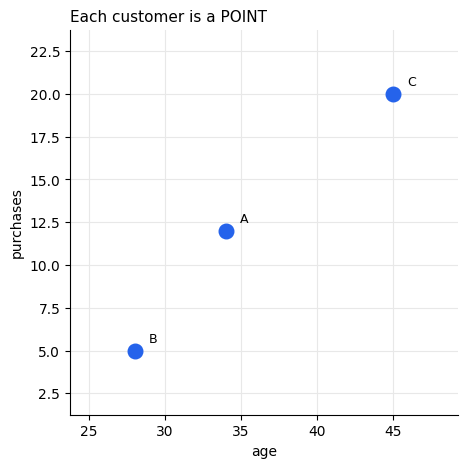

In [ ]:
draw_points(x=customers[:, 0],          # column 0 = age
            y=customers[:, 2],          # column 2 = purchases
            names=["A", "B", "C"],
            xlabel="age", ylabel="purchases",
            title="Each customer is a POINT")

In [ ]:
# applicant loan
# 1 [age, income, loan, tenure, coapplicant, education, job]
# 2 [age, income, loan, tenure, coapplicant, education, job]

In [ ]:
last_month = np.array([2, 5, 1])
this_month = np.array([3, 1, 4])

print("total sales:  ", last_month + this_month)
print("change:   ", this_month - last_month)
print("doubled:  ", 2 * this_month)

total sales:   [5 6 5]
change:    [ 1 -4  3]
doubled:   [6 2 8]


In [ ]:
a = np.array([3, 5, 1])
b = np.array([1, 4])

print(a+b)

ValueError: operands could not be broadcast together with shapes (3,) (2,) 

## Dot Product
dot(a, b)

**Meaning 1 :** weighted sum of (weights and feature/input = prediction)

a1.b1 + a2.b2 + ...


In [ ]:
a = np.array([2, 5, 1])
b = np.array([3, 1, 4])

print( np.dot(a, b) )
print( a.dot(b) )
print( a @ b )

15
15
15


In [ ]:
# w.T x + b
# similar to the equation of line m.x + c {where m/w is weights and x/Tx is features and b/c is bias}
features = np.array([35, 55, 12])           # input by the user
weights = np.array([0.1, 0.5, 2.0])         # learnd by model/ML

predict = features @ weights
print("score:", predict)

score: 55.0


In [ ]:
# features_car = [odometer, milegage, power, engine, year]
# weights  = [-0.5, -0.2, 2.3, 1.8, -0.3]
# resale_price = np.dot(features_car, weights)

#                 free  meeting  winner  report
# email  = np.array([ 3,     0,      2,      0])     # this email
email  = np.array([ 1,     5,      0,      3])     # this email
weights=np.array([ 1.2,  -0.9,    1.8,   -1.1])   # learned

score = np.dot(email, weights)
print("spam score:", score.round(2))
print("result:", "SPAM" if score > 0 else "not spam")

spam score: -6.6
result: not spam


## Dot Product
**Meaning 2:** how 2 vectors are alinged (same direction of not)

dot(a,b) = |a|.|b|.cos(angle)

- represents similarity of 2 vectors

In [ ]:
# np.dot(a, b)

In [ ]:
#               [electronics spend, groceries spend]
tech      = np.array([ 4, 1])
tech2     = np.array([ 5, 1])
groceries = np.array([ -2, 4])

In [ ]:
print("tech @ tech2 :", tech.dot(tech2)) # similar taste.
print("tech @ groceries :", tech.dot(groceries)) # opposite taste

tech @ tech2 : 21
tech @ groceries : -4


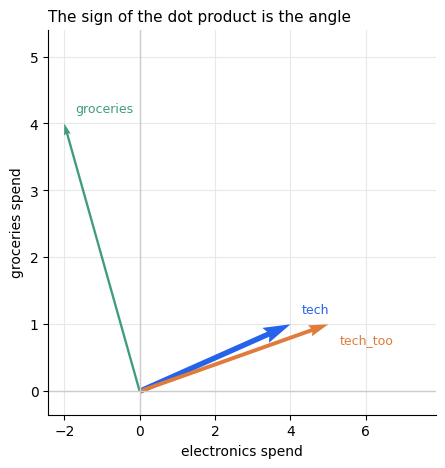

In [ ]:
draw_vectors("The sign of the dot product is the angle",
             axes=("electronics spend", "groceries spend"),
             tech=tech, tech_too=tech2, groceries=groceries)

Puzzle:
1. Make two vectors of length 4: `week1` and `week2`
2. Add them to get `total`
3. Make a `weights` vector of length 4 and compute `total @ weights`

In [ ]:
week1 = np.array([3, 1, 5, 0])
week2 = np.array([6, 2, 4, 1])
total = week1 + week2

weights = np.array([0.1, -0.4, 0.6, -1.0])
predict = weights @ total
print(predict)

4.1


In [ ]:
v = np.array([3, 4])
print("length:", np.linalg.norm(v))

length: 5.0


In [ ]:
print(total)
print("length:", np.linalg.norm(total))

[9 3 9 1]
length: 13.114877048604


In [ ]:
a = np.array([1, 3])
b = np.array([4, 1])
c = b-a
print("b-a :", c)
print("length:", np.linalg.norm(b-a))

b-a : [ 3 -2]
length: 3.605551275463989


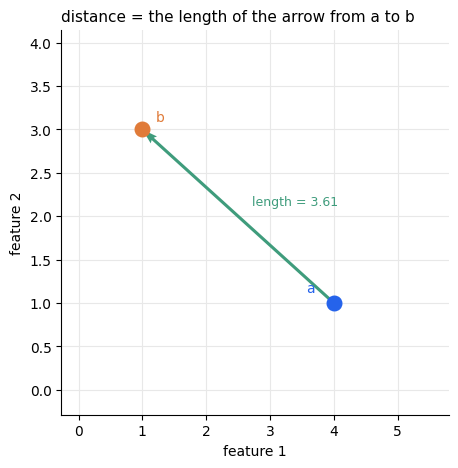

In [ ]:
draw_distance(b, a)

## Cosine similarity
 - dot product divided by the norm of vectors.
 - cosine angle between 2 vectors.
 - only looks at the direction (not the magnitude)



```
 a.b = |a| . |b| cos(angle)
 cos(angle) = a.b / |a|.|b|
```

range : [-1, +1]



In [ ]:
#                          laptop  cooking-recipees
short_tech = np.array([        3,     1])
long_tech  = np.array([        30,     10])
cooking    = np.array([        0,     5])

In [ ]:
def cosine(a, b):
    return np.dot(a, b) / ( np.linalg.norm(a) * np.linalg.norm(b) )

In [ ]:
cosine(short_tech, long_tech)

np.float64(1.0)

In [ ]:
cosine(short_tech, cooking)

np.float64(0.3162277660168379)

In [ ]:
def unit(a):    #converting vector into unit vector
    return a / np.linalg.norm(a)    # np.linalg.norm(a) gives `|a|` magnitude of the vector

In [ ]:
v = np.array([3, 4])
v_unit = unit(v)
print(v)
print(v_unit)

[3 4]
[0.6 0.8]


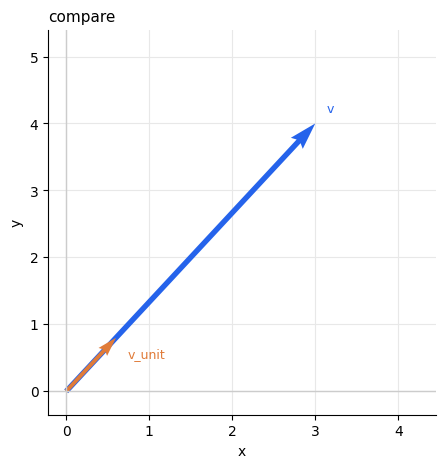

In [ ]:
draw_vectors("compare", axes = ("x", "y"), v = v, v_unit = v_unit);

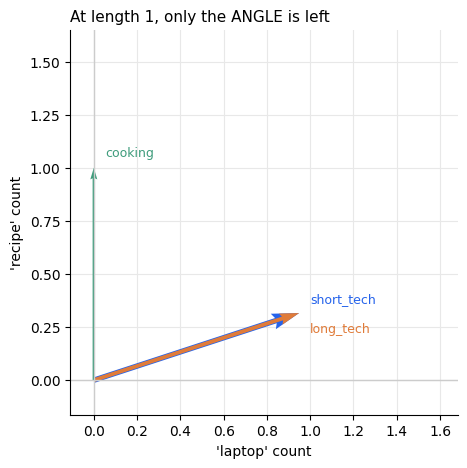

In [ ]:
draw_vectors("At length 1, only the ANGLE is left",
             axes=("'laptop' count", "'recipe' count"),
             short_tech=unit(short_tech),
             long_tech=unit(long_tech),
             cooking=unit(cooking))

## Matrix Multiplication

In [ ]:
A = np.random.randint(1, 10, (2, 4))
B = np.random.randint(1, 10, (4, 5))
print(A)
print(A.shape)
print(B)
print(B.shape)

[[1 1 4 1]
 [9 9 1 6]]
(2, 4)
[[3 7 5 7 2]
 [6 5 9 9 9]
 [3 8 9 8 9]
 [9 8 2 8 2]]
(4, 5)


In [ ]:
# element wise multiplication.
print(A * B)

ValueError: operands could not be broadcast together with shapes (2,4) (4,5) 

In [ ]:
# matrix multiplication.
np.dot(A, B)

array([[ 30,  52,  52,  56,  49],
       [138, 164, 147, 200, 120]])

In [ ]:
A @ B

array([[ 30,  52,  52,  56,  49],
       [138, 164, 147, 200, 120]])

In [ ]:
A

array([[1, 1, 4, 1],
       [9, 9, 1, 6]])

In [ ]:
# transpose of vector / matrix
A.T

array([[1, 9],
       [1, 9],
       [4, 1],
       [1, 6]])

In [ ]:
A @ A       # np.dot(A, A)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

In [ ]:
A @ A.T

array([[ 19,  28],
       [ 28, 199]])

In [ ]:
# model.predict(X_test)  : y_pred = X_tests @ weights

customers = np.array([
    [34, 55, 12],
    [28, 42,  5],
    [45, 68, 20],
    [39, 50,  9],
])

weights = np.array([0.1, 0.5, 2.0])

customers @ weights

array([54.9, 33.8, 78.5, 46.9])

In [ ]:
# model.fit(X_train, y_train)

# Recommendation System.

In [ ]:
# users, movies, ratings
# Mohit, Intersaller , 5
# Ankit , Titanic, 3

# 500 M users.
users  = ["Aisha", "Bilal", "Chen", "Divya", "Erik"]
movies = ["Fight Club", "KGF", "chand mera dil", "Musafir cafe", "Jiro dreams of shushi'"]

R = np.array([
    [5, 0, 1, 0, 2],     # Aisha
    [4, 5, 0, 1, 1],     # Bilal
    [0, 1, 5, 4, 2],     # Chen
    [1, 0, 4, 5, 3],     # Divya
    [1, 1, 1, 1, 5],     # Erik
])

print("shape:", R.shape, "-> 5 users (rows) x 5 movies (columns)")

shape: (5, 5) -> 5 users (rows) x 5 movies (columns)


In [ ]:
# i want to convert all the vectors to unit vectors.....
R_unit = np.array([unit(user) for user in R])
R_unit

array([[0.91, 0.  , 0.18, 0.  , 0.37],
       [0.61, 0.76, 0.  , 0.15, 0.15],
       [0.  , 0.15, 0.74, 0.59, 0.29],
       [0.14, 0.  , 0.56, 0.7 , 0.42],
       [0.19, 0.19, 0.19, 0.19, 0.93]])

In [ ]:
S = R_unit @ R_unit.T
S # cosine similary of every user with other userssss.

array([[1.  , 0.61, 0.24, 0.38, 0.54],
       [0.61, 1.  , 0.25, 0.26, 0.42],
       [0.24, 0.25, 1.  , 0.95, 0.55],
       [0.38, 0.26, 0.95, 1.  , 0.65],
       [0.54, 0.42, 0.55, 0.65, 1.  ]])

In [ ]:
show_table(S, users, "Cosine similarity between every pair of users:")

Cosine similarity between every pair of users:
            Aisha    Bilal     Chen    Divya     Erik
  Aisha      1.00     0.61     0.24     0.38     0.54
  Bilal      0.61     1.00     0.25     0.26     0.42
   Chen      0.24     0.25     1.00     0.95     0.55
  Divya      0.38     0.26     0.95     1.00     0.65
   Erik      0.54     0.42     0.55     0.65     1.00


In [ ]:
# Aisha has login to netflix,
# i want to recommend a new movie to Aisha.
aisha = S[0].copy()
aisha[0] = 0
match = np.argmax(aisha)
print("closest user to Aisha:", users[match])
R[match, 1] # recommend the movie idx 1
print("Recommende movie -", movies[1])

closest user to Aisha: Bilal
Recommende movie - KGF


In [ ]:
# scalars,
# vectors
# matrix
# transpose
# dot product - 1
# dot product - 2
# vector norm
# unit vector
# cosine-sim (angle between 2 vectors)
# matmul
# mini-case study

# inverse, eigen values, projection